# Final — Blend v04 + v05

A v04 (só numéricas) e a v05 (numéricas + times) erram de formas diferentes: a v05 é melhor em 2017/2021, a v04 em 2018/2020. Aqui testo uma média ponderada das duas.

O peso é escolhido **apenas** nas previsões out-of-fold da validação temporal (nunca no placar). Depois treino os dois modelos em todo o `train.csv` e aplico o mesmo peso no teste.

In [1]:
import warnings
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)

DATA = Path('../data')
SUB_DIR = Path('../submissions')
SUB_DIR.mkdir(exist_ok=True)
LOG_PATH = Path('../experimentos.csv')

CLASS_ORDER = ['A', 'D', 'H']
RANDOM_STATE = 42
FOLDS = [2016, 2017, 2018, 2019, 2020, 2021]  # walk-forward: treino = temporadas anteriores

train = pd.read_csv(DATA / 'train.csv')
test = pd.read_csv(DATA / 'test.csv')
print(train.shape, test.shape)

(3419, 26) (1725, 22)


In [2]:
NUM_FEATURES = ['elo_home', 'elo_away', 'elo_diff', 'form_pts_home', 'form_pts_away',
                'form_gf_home', 'form_ga_home', 'form_gf_away', 'form_ga_away',
                'home_form_as_host', 'away_form_as_visitor', 'rest_days_home', 'rest_days_away',
                'season_ppg_home', 'season_ppg_away', 'round_n', 'h2h_home_pts']


def add_features(df):
    """Features derivadas usando apenas colunas da propria linha."""
    out = df.copy()
    out['venue_form_diff'] = out['home_form_as_host'] - out['away_form_as_visitor']
    out['form_pts_diff'] = out['form_pts_home'] - out['form_pts_away']
    out['gd_diff'] = (out['form_gf_home'] - out['form_ga_home']) - (out['form_gf_away'] - out['form_ga_away'])
    return out


train = add_features(train)
test = add_features(test)

In [3]:
def make_logreg(num_cols, cat_cols=(), C=1.0):
    transformers = [('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                                      ('scale', StandardScaler())]), list(num_cols))]
    if cat_cols:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore'), list(cat_cols)))
    return Pipeline([('prep', ColumnTransformer(transformers)),
                     ('model', LogisticRegression(C=C, max_iter=5000, random_state=RANDOM_STATE))])


def predict_ordered(model, X):
    """Alinha predict_proba a ['A', 'D', 'H'] pelas classes do modelo."""
    raw = pd.DataFrame(model.predict_proba(X), columns=model.named_steps['model'].classes_)
    return raw.reindex(columns=CLASS_ORDER, fill_value=0.0).values


def walk_forward(build, cols):
    """Previsoes out-of-fold por temporada; o modelo e reconstruido do zero a cada fold."""
    preds, ys = {}, {}
    for season in FOLDS:
        tr = train[train['Season'] < season]
        va = train[train['Season'] == season]
        model = build()
        model.fit(tr[cols], tr['Res'])
        preds[season] = predict_ordered(model, va[cols])
        ys[season] = va['Res'].values
    return preds, ys


def summarize(preds, ys, name):
    rows = [{'Season': s, 'n': len(ys[s]), 'LogLoss': log_loss(ys[s], preds[s], labels=CLASS_ORDER)}
            for s in FOLDS]
    df = pd.DataFrame(rows)
    mean = np.average(df['LogLoss'], weights=df['n'])
    print(f'{name}: media ponderada = {mean:.4f} | desvio entre folds = {df.LogLoss.std():.4f}')
    return df, mean

In [4]:
def save_submission(proba, path):
    sub = pd.DataFrame(proba, columns=CLASS_ORDER)
    sub.insert(0, 'Id', test['Id'].values)
    assert list(sub.columns) == ['Id', 'A', 'D', 'H']
    assert len(sub) == len(test) and (sub['Id'].values == test['Id'].values).all()
    vals = sub[CLASS_ORDER].values
    assert np.isfinite(vals).all() and (vals > 0).all()
    assert np.allclose(vals.sum(axis=1), 1.0, atol=1e-9)
    sub.to_csv(path, index=False)
    print('salvo em', path, sub.shape)
    return sub


def log_experiment(version, change, features, model_desc, params, folds_df, mean, decision, csv_path):
    row = {'versao': version, 'data': date.today().isoformat(), 'mudanca': change,
           'features': features, 'modelo': model_desc, 'parametros': params,
           'folds': ','.join(map(str, FOLDS)),
           'logloss_por_fold': ';'.join(f'{s}:{v:.4f}' for s, v in zip(folds_df.Season, folds_df.LogLoss)),
           'logloss_medio': round(mean, 4), 'desvio': round(folds_df.LogLoss.std(), 4),
           'decisao': decision, 'csv': csv_path}
    log = pd.read_csv(LOG_PATH) if LOG_PATH.exists() else pd.DataFrame(columns=list(row.keys()))
    log = log[log['versao'] != version]
    log = pd.concat([log, pd.DataFrame([row])], ignore_index=True)
    log.to_csv(LOG_PATH, index=False)
    return log

In [5]:
NUM = ['elo_diff', 'venue_form_diff', 'form_pts_away']
CAT = ['Home', 'Away']

def build_v04():
    return make_logreg(NUM, C=0.03)

def build_v05():
    return make_logreg(NUM, CAT, C=0.01)

p04, ys = walk_forward(build_v04, NUM)
p05, _ = walk_forward(build_v05, NUM + CAT)

blends = {}
for w in [0.0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]:
    preds = {s: (1 - w) * p04[s] + w * p05[s] for s in FOLDS}
    blends[w] = summarize(preds, ys, f'peso v05 = {w}')

peso v05 = 0.0: media ponderada = 1.0222 | desvio entre folds = 0.0402
peso v05 = 0.2: media ponderada = 1.0220 | desvio entre folds = 0.0399
peso v05 = 0.3: media ponderada = 1.0219 | desvio entre folds = 0.0397
peso v05 = 0.4: media ponderada = 1.0218 | desvio entre folds = 0.0396
peso v05 = 0.5: media ponderada = 1.0218 | desvio entre folds = 0.0395
peso v05 = 0.6: media ponderada = 1.0218 | desvio entre folds = 0.0394
peso v05 = 0.7: media ponderada = 1.0218 | desvio entre folds = 0.0392
peso v05 = 0.8: media ponderada = 1.0218 | desvio entre folds = 0.0391
peso v05 = 1.0: media ponderada = 1.0218 | desvio entre folds = 0.0389


In [6]:
W = 0.5
df, m = blends[W]
tab = pd.DataFrame({'v04': blends[0.0][0].LogLoss.values, 'v05': blends[1.0][0].LogLoss.values,
                    'blend 0.5': df.LogLoss.values}, index=FOLDS)
tab.loc['media ponderada'] = [blends[0.0][1], blends[1.0][1], m]
tab.round(4)

,v04,v05,blend 0.5
2016,0.9976,0.9978,0.9975
2017,1.0858,1.0824,1.0838
2018,0.9808,0.9821,0.9812
2019,0.9905,0.9904,0.9903
2020,1.0467,1.0479,1.0470
2021,1.0320,1.0303,1.0309
media ponderada,1.0222,1.0218,1.0218


A curva é bem plana entre 0.4 e 0.7; escolho `W=0.5` por ser o ponto central, menos dependente de ajuste fino. O blend fica melhor que os dois modelos isolados na média.

## Calibração

Checagem nas previsões out-of-fold: probabilidade média prevista × frequência observada, por faixa.

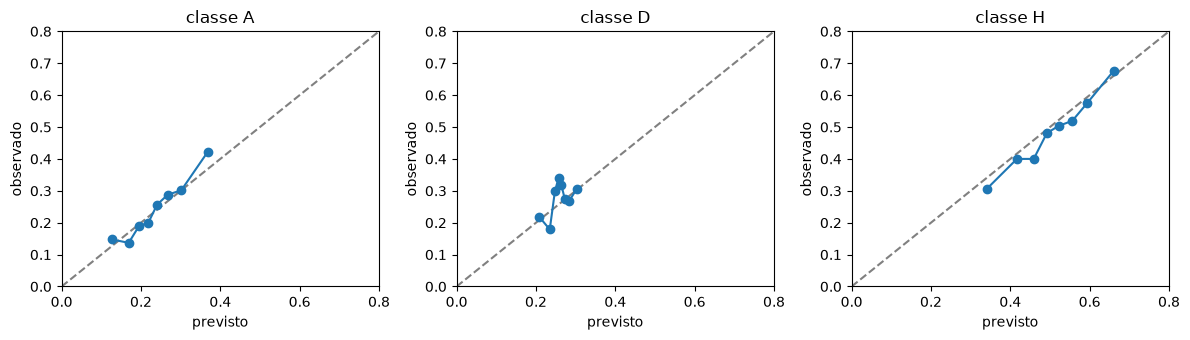

media prevista: [0.236 0.259 0.505] | observada: [np.float64(0.243), np.float64(0.275), np.float64(0.483)]


In [7]:
import matplotlib.pyplot as plt

P = np.vstack([(1 - W) * p04[s] + W * p05[s] for s in FOLDS])
Y = np.concatenate([ys[s] for s in FOLDS])
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for i, cls in enumerate(CLASS_ORDER):
    g = pd.DataFrame({'p': P[:, i], 'y': (Y == cls).astype(float)})
    g['faixa'] = pd.qcut(g['p'], 8, duplicates='drop')
    g = g.groupby('faixa', observed=True).mean()
    axes[i].plot([0, 1], [0, 1], '--', color='gray')
    axes[i].plot(g['p'], g['y'], 'o-')
    axes[i].set_title(f'classe {cls}')
    axes[i].set_xlabel('previsto')
    axes[i].set_ylabel('observado')
    axes[i].set_xlim(0, 0.8)
    axes[i].set_ylim(0, 0.8)
plt.tight_layout()
plt.show()
print('media prevista:', P.mean(axis=0).round(3), '| observada:', [round((Y == c).mean(), 3) for c in CLASS_ORDER])

## Treino final e submissão

In [8]:
m04 = build_v04().fit(train[NUM], train['Res'])
m05 = build_v05().fit(train[NUM + CAT], train['Res'])
proba = (1 - W) * predict_ordered(m04, test[NUM]) + W * predict_ordered(m05, test[NUM + CAT])
sub = save_submission(proba, SUB_DIR / 'submission_final.csv')
log_experiment('final', 'blend 0.5*v04 + 0.5*v05', ','.join(NUM + CAT), 'blend de 2 LogisticRegression',
               'v04 C=0.03; v05 C=0.01; W=0.5', df, m, 'campeao final', 'submissions/submission_final.csv')

salvo em ..\submissions\submission_final.csv (1725, 4)


,versao,data,mudanca,features,modelo,parametros,folds,logloss_por_fold,logloss_medio,desvio,decisao,csv
0,v01,2026-09-28,baseline logreg,17 numericas,LogisticRegression,C=1,"2016,2017,2018,2019,2020,2021",2016:1.0119;2017:1.1087;2018:0.9857;2019:0.997...,1.0337,0.0455,campeao inicial,submissions/submission_v01.csv
1,v02,2026-09-28,ajuste de C,17 numericas,LogisticRegression,C=0.003,"2016,2017,2018,2019,2020,2021",2016:1.0017;2017:1.0924;2018:0.9839;2019:1.000...,1.0273,0.0403,promovido,submissions/submission_v02.csv
2,v03,2026-09-28,selecao: so elo_diff (arvores rejeitadas),elo_diff,LogisticRegression,C=0.1,"2016,2017,2018,2019,2020,2021",2016:0.9969;2017:1.0875;2018:0.9800;2019:0.989...,1.0228,0.0414,promovido,submissions/submission_v03.csv
3,v04,2026-09-28,+venue_form_diff +form_pts_away,"elo_diff,venue_form_diff,form_pts_away",LogisticRegression,C=0.03,"2016,2017,2018,2019,2020,2021",2016:0.9976;2017:1.0858;2018:0.9808;2019:0.990...,1.0222,0.0402,promovido,submissions/submission_v04.csv
4,v05,2026-09-28,+ Home/Away one-hot,"elo_diff,venue_form_diff,form_pts_away,Home,Away",LogisticRegression,C=0.01,"2016,2017,2018,2019,2020,2021",2016:0.9978;2017:1.0824;2018:0.9821;2019:0.990...,1.0218,0.0389,promovido,submissions/submission_v05.csv
5,final,2026-09-28,blend 0.5*v04 + 0.5*v05,"elo_diff,venue_form_diff,form_pts_away,Home,Away",blend de 2 LogisticRegression,v04 C=0.03; v05 C=0.01; W=0.5,"2016,2017,2018,2019,2020,2021",2016:0.9975;2017:1.0838;2018:0.9812;2019:0.990...,1.0218,0.0395,campeao final,submissions/submission_final.csv


In [9]:
print(sub.describe().round(3))
pd.read_csv(LOG_PATH)[['versao', 'mudanca', 'logloss_medio', 'desvio', 'decisao', 'csv']]

             Id         A         D         H
count  1725.000  1725.000  1725.000  1725.000
mean   4281.000     0.242     0.270     0.489
std     498.109     0.083     0.031     0.107
min    3419.000     0.059     0.153     0.157
25%    3850.000     0.180     0.250     0.412
50%    4281.000     0.234     0.274     0.489
75%    4712.000     0.296     0.292     0.565
max    5143.000     0.571     0.344     0.788


,versao,mudanca,logloss_medio,desvio,decisao,csv
0,v01,baseline logreg,1.0337,0.0455,campeao inicial,submissions/submission_v01.csv
1,v02,ajuste de C,1.0273,0.0403,promovido,submissions/submission_v02.csv
2,v03,selecao: so elo_diff (arvores rejeitadas),1.0228,0.0414,promovido,submissions/submission_v03.csv
3,v04,+venue_form_diff +form_pts_away,1.0222,0.0402,promovido,submissions/submission_v04.csv
4,v05,+ Home/Away one-hot,1.0218,0.0389,promovido,submissions/submission_v05.csv
5,final,blend 0.5*v04 + 0.5*v05,1.0218,0.0395,campeao final,submissions/submission_final.csv
